/var/folders/h5/1rb1tj8x0vs85cxtszq9_hdm0000gn/T/ipykernel_38588/325407711.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean.iloc[:, 0], ax=axes[0], palette="viridis")
/var/folders/h5/1rb1tj8x0vs85cxtszq9_hdm0000gn/T/ipykernel_38588/325407711.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean.iloc[:, 1], ax=axes[1], palette="magma")


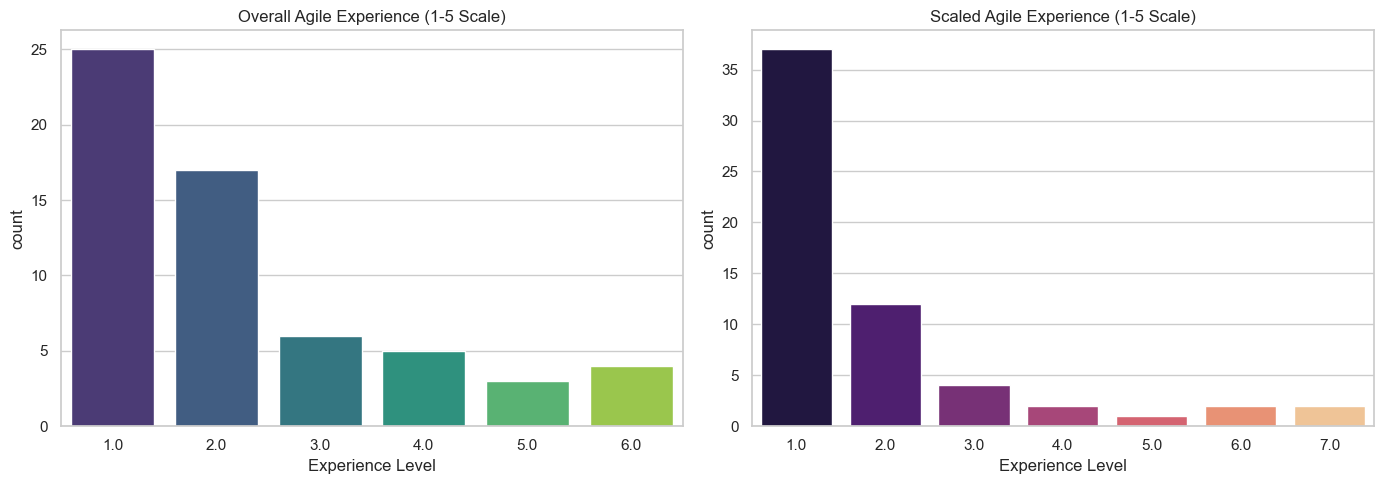

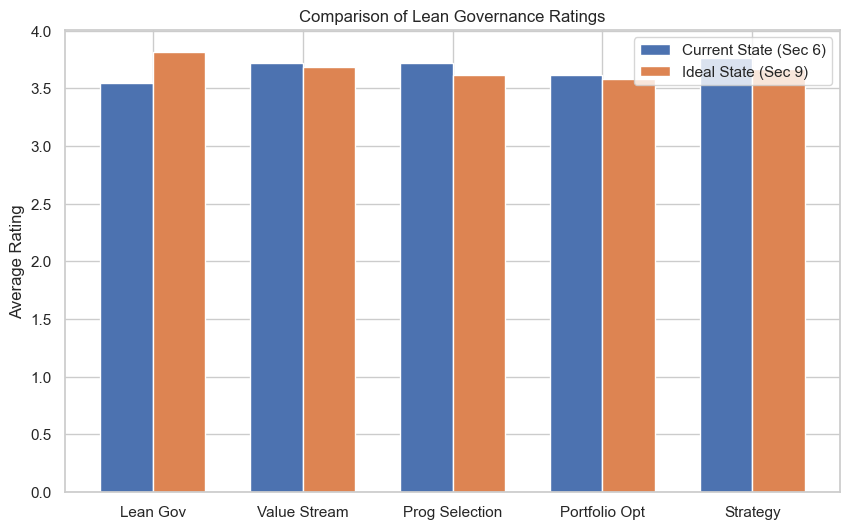

/var/folders/h5/1rb1tj8x0vs85cxtszq9_hdm0000gn/T/ipykernel_38588/325407711.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cdp_labels, y=cdp_cols.values, palette="rocket")


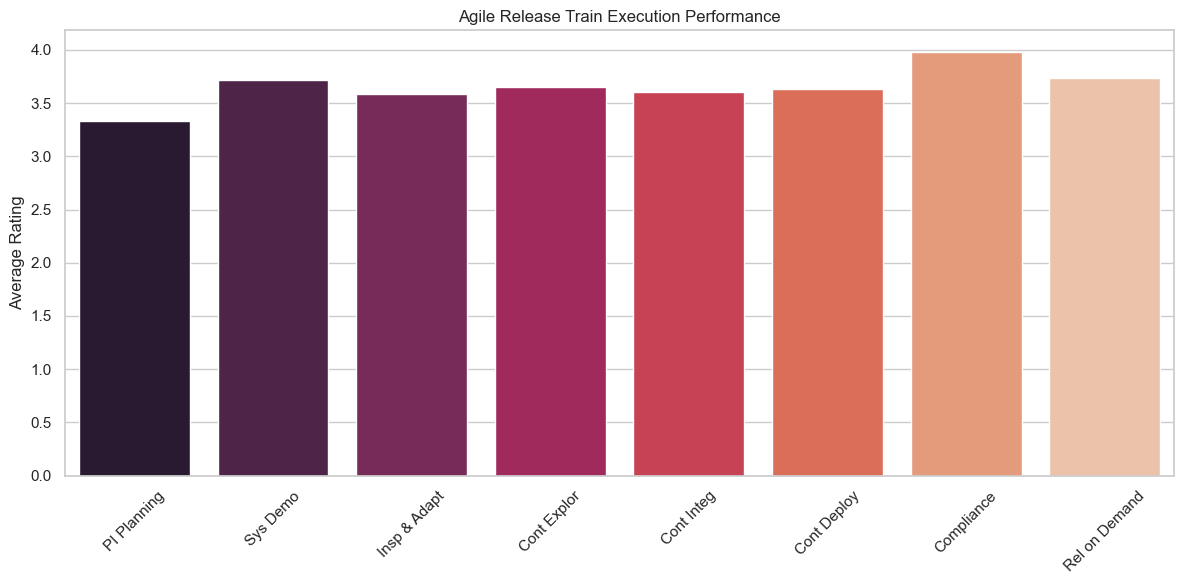

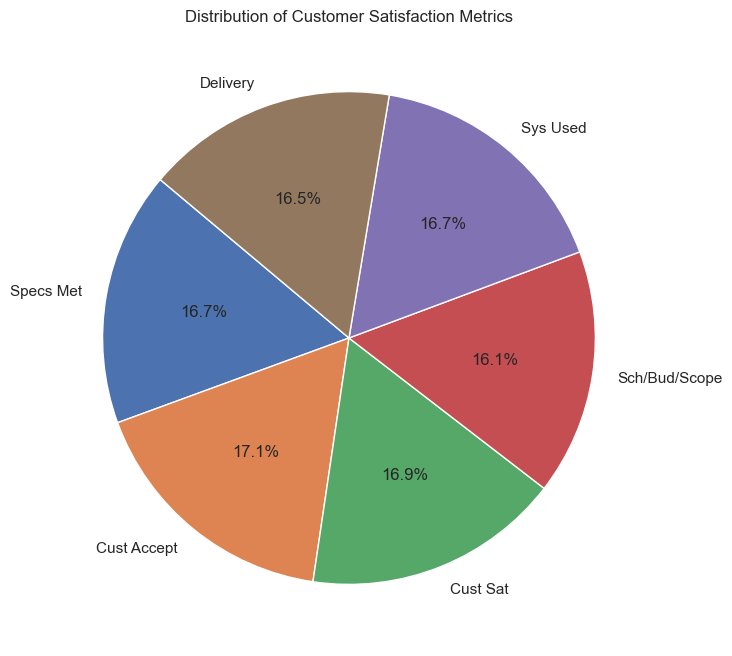

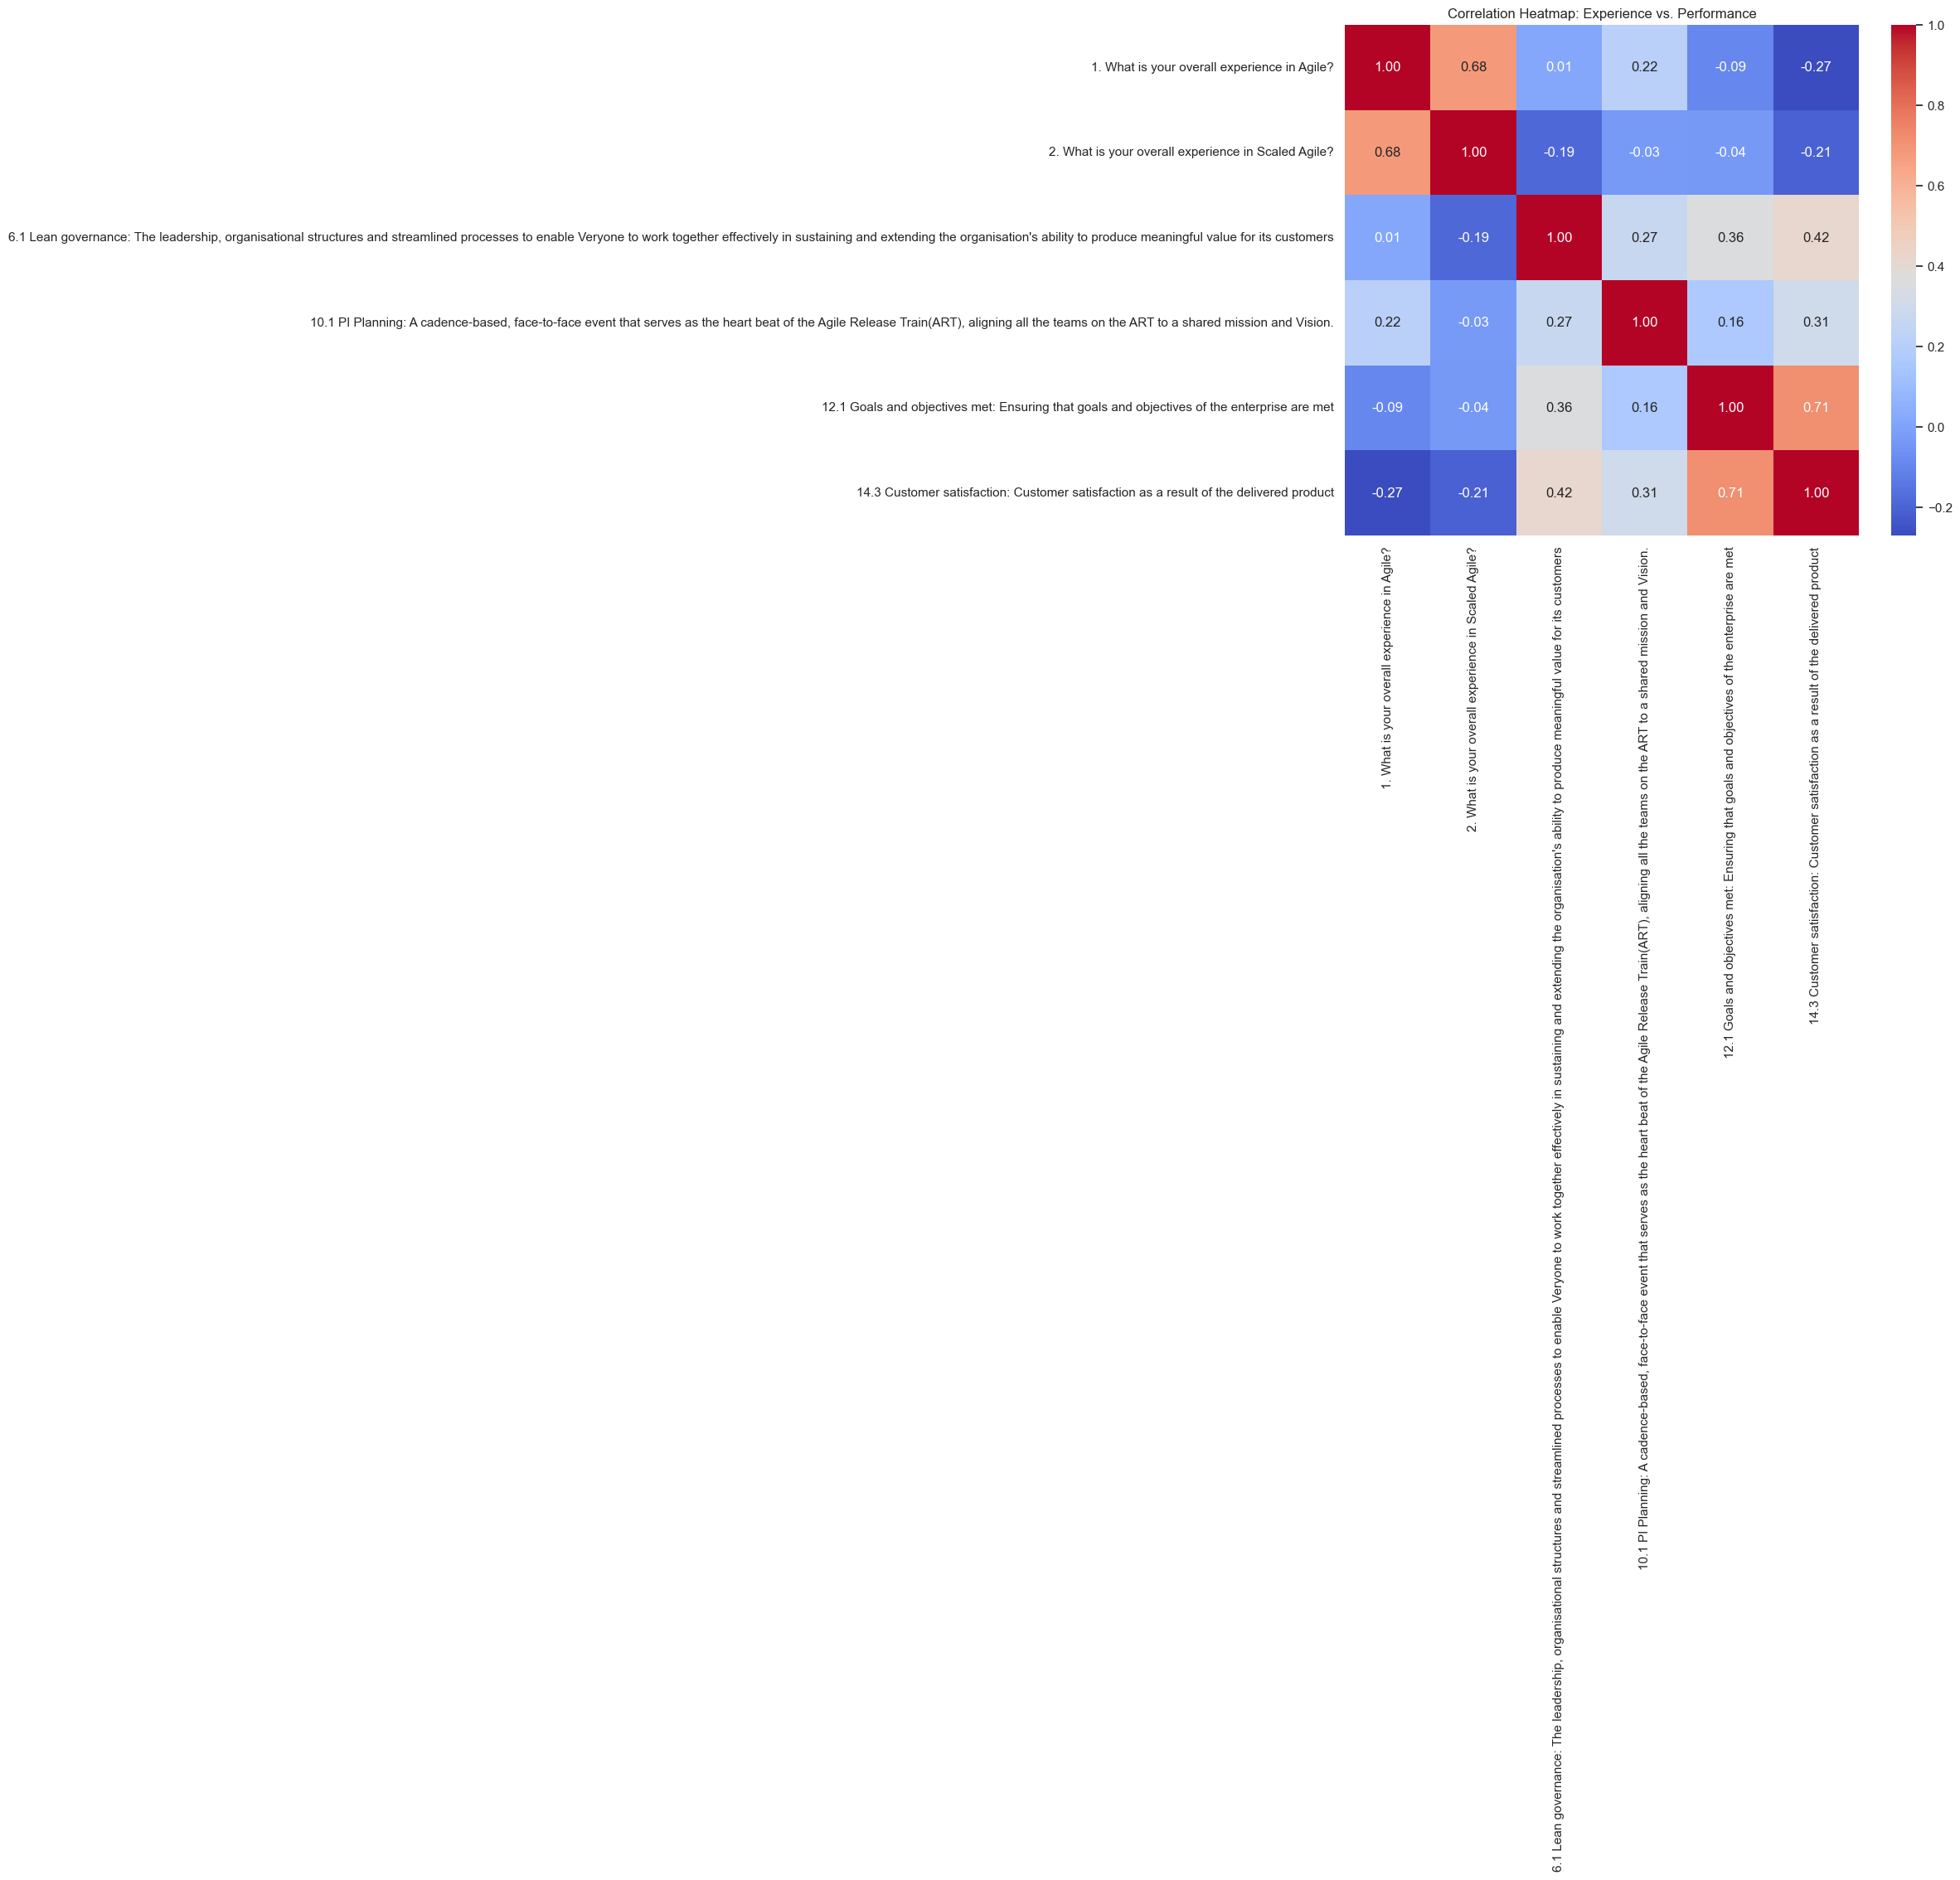

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the data
file_path = 'Conceptual Framework for Scaled Agile Success (Responses) - Copy.csv'
df = pd.read_csv(file_path, sep=';')

# 2. Data Cleaning
# Remove entirely empty rows and columns
df_clean = df.dropna(how='all').iloc[:60] 
df_clean = df_clean.dropna(axis=1, how='all')

# 3. Setting Plotting Style
sns.set(style="whitegrid")

# 4. Demographics Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x=df_clean.iloc[:, 0], ax=axes[0], palette="viridis")
axes[0].set_title('Overall Agile Experience (1-5 Scale)')
axes[0].set_xlabel('Experience Level')

sns.countplot(x=df_clean.iloc[:, 1], ax=axes[1], palette="magma")
axes[1].set_title('Scaled Agile Experience (1-5 Scale)')
axes[1].set_xlabel('Experience Level')
plt.tight_layout()
plt.show()

# 5. Lean Governance Comparison (Section 6 vs Section 9)
gov_cols_6 = df_clean.iloc[:, [5, 6, 7, 8, 9]].mean()
gov_cols_9 = df_clean.iloc[:, [23, 24, 25, 26, 27]].mean()

labels = ['Lean Gov', 'Value Stream', 'Prog Selection', 'Portfolio Opt', 'Strategy']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, gov_cols_6.values, width, label='Current State (Sec 6)')
plt.bar(x + width/2, gov_cols_9.values, width, label='Ideal State (Sec 9)')
plt.ylabel('Average Rating')
plt.title('Comparison of Lean Governance Ratings')
plt.xticks(x, labels)
plt.legend()
plt.show()

# 6. Agile Release Train (ART) Execution (Section 10)
cdp_cols = df_clean.iloc[:, 28:36].mean()
cdp_labels = ['PI Planning', 'Sys Demo', 'Insp & Adapt', 'Cont Explor', 
              'Cont Integ', 'Cont Deploy', 'Compliance', 'Rel on Demand']

plt.figure(figsize=(12, 6))
sns.barplot(x=cdp_labels, y=cdp_cols.values, palette="rocket")
plt.xticks(rotation=45)
plt.title('Agile Release Train Execution Performance')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

# 7. Customer Satisfaction & Delivery (Section 14)
cust_cols = df_clean.iloc[:, 58:64].mean()
cust_labels = ['Specs Met', 'Cust Accept', 'Cust Sat', 'Sch/Bud/Scope', 'Sys Used', 'Delivery']

plt.figure(figsize=(8, 8))
plt.pie(cust_cols.values, labels=cust_labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Customer Satisfaction Metrics')
plt.show()

# 8. Correlation Analysis
# Analyzing relationships between experience and key outcomes
key_cols = [df_clean.columns[0], df_clean.columns[1], df_clean.columns[5], 
            df_clean.columns[28], df_clean.columns[41], df_clean.columns[60]]
corr_data = df_clean[key_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Experience vs. Performance')
plt.show()